Sample Rate: 48000 Hz
Duration: 15.00 seconds


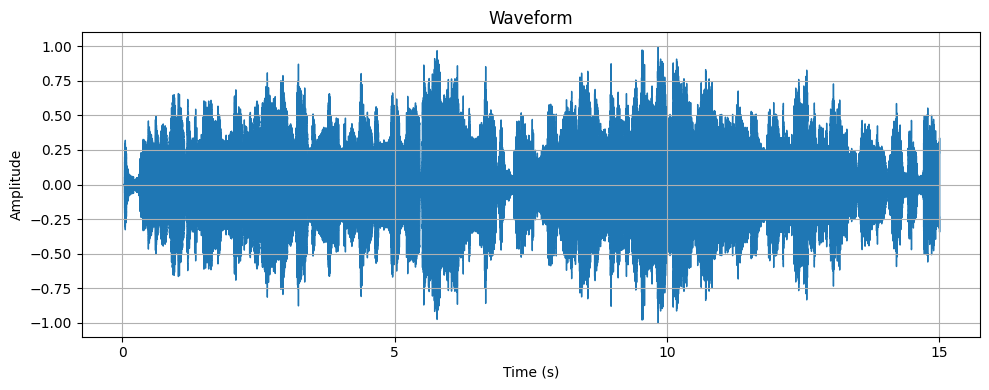

In [1]:
import librosa
import librosa.display
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the audio file
audio_path = "data/song_with_2piccolo.wav"
y, sr = librosa.load(audio_path, sr=None) # sr stands for sampling rate

# 2. Print sampling rate and duration
print(f"Sample Rate: {sr} Hz")
print(f"Duration: {len(y) / sr:.2f} seconds")

# 3. Normalize audio
y_normalized = y / np.max(np.abs(y))

# 4. Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(y_normalized, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


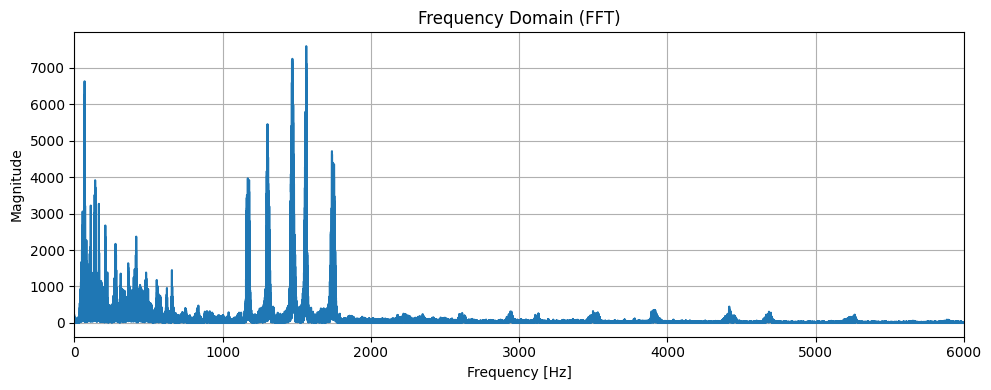

Frequencies Detected: [1500.]


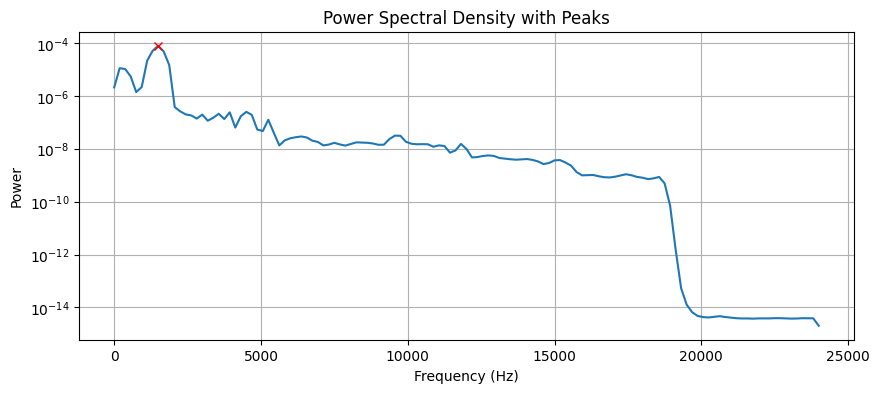

In [2]:
from scipy.signal import welch
# === 3. FFT Analysis ===
n = len(y)
Y = np.fft.fft(y)
freqs = np.fft.fftfreq(n, 1/sr)

# Take only positive frequencies
Y = Y[:n//2]
freqs = freqs[:n//2]
magnitude = np.abs(Y)

# Plot FFT
plt.figure(figsize=(10, 4))
plt.plot(freqs, magnitude)
plt.title("Frequency Domain (FFT)")
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude")
plt.grid(True)
plt.tight_layout()
plt.xlim(0, 6000)
plt.show()

# Calculate Power Spectral Density (PSD) using Welch's method
f, Pxx = welch(y, sr)

from scipy.signal import find_peaks
peaks, _ = find_peaks(Pxx, height=np.max(Pxx)*0.004, distance=50)
peak_freqs = f[peaks]
print("Frequencies Detected:", peak_freqs)

plt.figure(figsize=(10, 4))
plt.semilogy(f, Pxx)
plt.plot(peak_freqs, Pxx[peaks], 'rx')
plt.title("Power Spectral Density with Peaks")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power")
plt.grid()
plt.show()

🔇 Applying Filter at 1500.00 Hz ±30.0 Hz


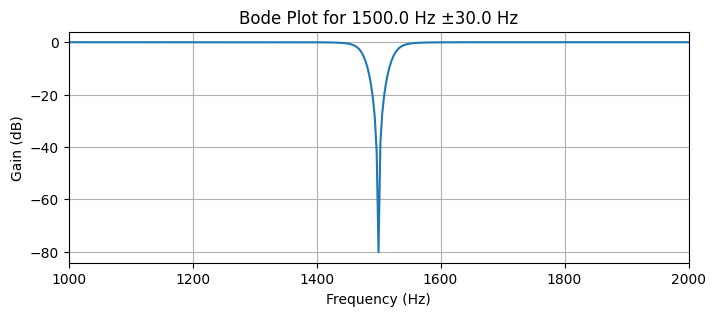

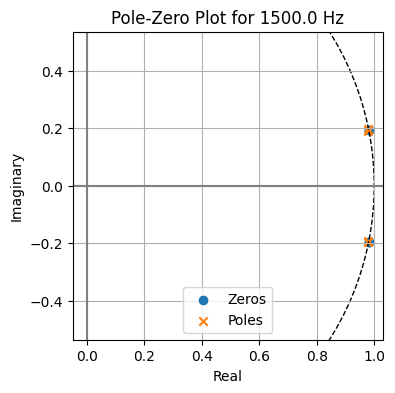

In [3]:
import scipy.signal as signal
def analyze_filter(freq, sr, width=60):
    nyq = sr / 2
    low = max((freq - width/2) / nyq, 0.001)
    high = min((freq + width/2) / nyq, 0.999)
    b, a = signal.butter(N=2, Wn=[low, high], btype='bandstop')

    # Bode Plot
    w, h = signal.freqz(b, a, worN=8000)
    plt.figure(figsize=(8, 3))
    plt.plot(w * sr / (2 * np.pi), 20 * np.log10(abs(h)))
    plt.title(f"Bode Plot for {freq:.1f} Hz ±{width/2:.1f} Hz")
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Gain (dB)")
    plt.grid()
    plt.xlim(1000,2000)
    plt.show()

    # Pole-Zero Plot
    z, p, _ = signal.tf2zpk(b, a)
    plt.figure(figsize=(4, 4))
    plt.scatter(np.real(z), np.imag(z), marker='o', label='Zeros')
    plt.scatter(np.real(p), np.imag(p), marker='x', label='Poles')
    plt.axhline(0, color='gray')
    plt.axvline(0, color='gray')
    unit_circle = plt.Circle((0, 0), 1, color='black', fill=False, linestyle='--')
    plt.gca().add_artist(unit_circle)
    plt.title(f"Pole-Zero Plot for {freq:.1f} Hz")
    plt.xlabel("Real")
    plt.ylabel("Imaginary")
    plt.legend()
    plt.axis('equal')
    plt.grid()
    plt.show()

    return b, a

def apply_bandstop(y, b, a):
    return signal.filtfilt(b, a, y)

y_filtered = y.copy() # Initialize y_filtered before the loop
notch_width = 60

for freq in peak_freqs:
    print(f"🔇 Applying Filter at {freq:.2f} Hz ±{notch_width/2} Hz")
    b, a = analyze_filter(freq, sr, width=notch_width)
    y_filtered = apply_bandstop(y_filtered, b, a)

In [4]:
from scipy.signal import butter, lfilter

def bandstop_filter(data, lowcut, highcut, sr, order=4):
    nyq = 0.5 * sr
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='bandstop')
    return lfilter(b, a, data)

# Example: remove 950 Hz – 2100 Hz
y_filtered = bandstop_filter(y, 1000, 4000, sr)


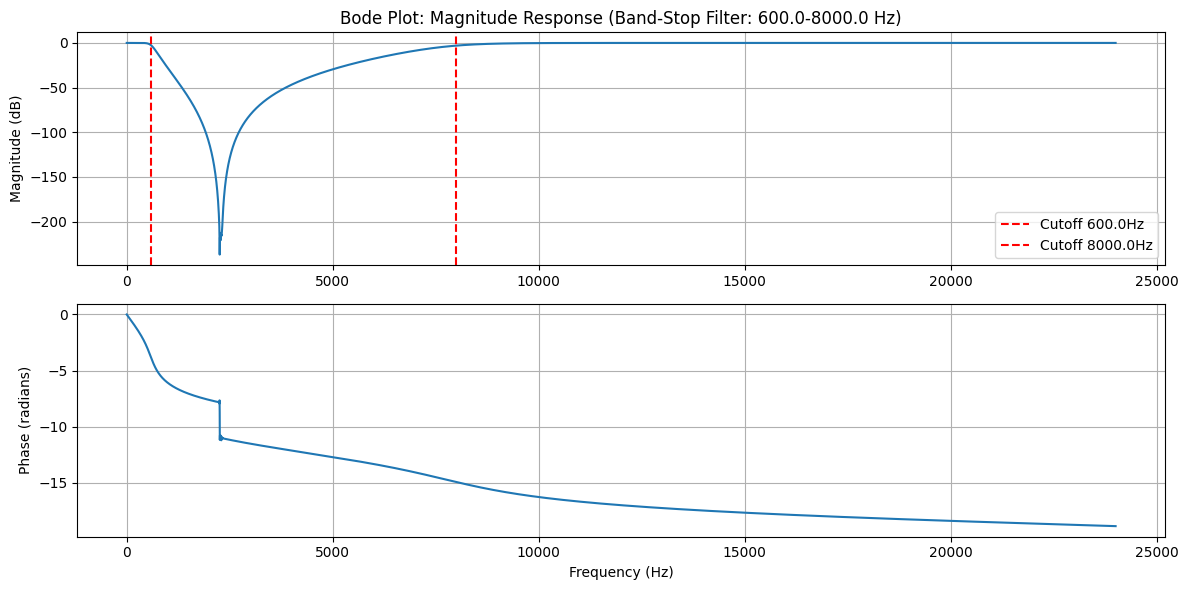

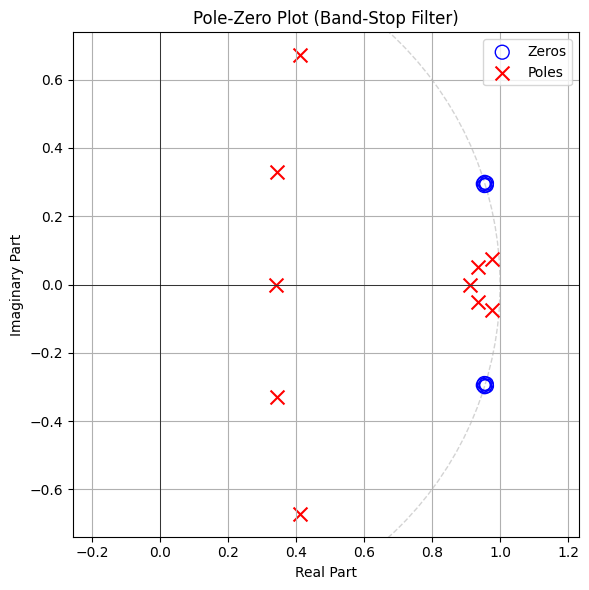

Filtered audio saved as 'song_piccolo_removed.wav'


In [7]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np


# Spectrogram before filtering
D = librosa.stft(y_normalized, n_fft=2048, hop_length=512)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)


from scipy.signal import butter, freqz, lfilter, filtfilt, tf2zpk
import soundfile as sf

# Designing a BAND-STOP Filter.

# 1. Identifying the FREQUENCY REGION from analysis which is a very crucial step.
# By visual inspection of the spectrogram that is by looking at the spectogram plot and analyzing where the unwanted picollo notes are present.
lowcut = 600.0   # Lower cutoff frequency in Hz.
highcut = 8000.0 # Upper cutoff frequency in Hz.
order = 5        # A slightly higher order for a sharper cutoff

# 2. Designing the correct filter type.
# Using btype='bandstop' so as to remove the frequencies in the specified range.
b, a = butter(order, [lowcut, highcut], btype='bandstop', fs=sr)

# 3. Analyzing the filter.

# Bode Plot.
w, h = freqz(b, a, worN=8000, fs=sr)
plt.figure(figsize=(12, 6))
plt.subplot(2, 1, 1)
plt.plot(w, 20 * np.log10(abs(h)))
plt.title(f'Bode Plot: Magnitude Response (Band-Stop Filter: {lowcut}-{highcut} Hz)')
plt.ylabel('Magnitude (dB)')
plt.axvline(lowcut, color='r', linestyle='--', label=f'Cutoff {lowcut}Hz')
plt.axvline(highcut, color='r', linestyle='--', label=f'Cutoff {highcut}Hz')
plt.grid(True); plt.legend()

plt.subplot(2, 1, 2)
plt.plot(w, np.unwrap(np.angle(h)))
plt.ylabel('Phase (radians)'); plt.xlabel('Frequency (Hz)'); plt.grid(True)
plt.tight_layout()
plt.show()

# Pole-Zero Plot.
z, p, k = tf2zpk(b, a)
plt.figure(figsize=(6, 6))
# Create the unit circle
unit_circle = plt.Circle((0,0), 1, color='lightgray', fill=False, linestyle='--')
plt.gca().add_artist(unit_circle)
plt.scatter(np.real(z), np.imag(z), marker='o', s=100, facecolors='none', edgecolors='b', label='Zeros')
plt.scatter(np.real(p), np.imag(p), marker='x', s=100, color='r', label='Poles')
plt.title("Pole-Zero Plot (Band-Stop Filter)")
plt.xlabel("Real Part"); plt.ylabel("Imaginary Part")
plt.axhline(0, color='black', lw=0.5); plt.axvline(0, color='black', lw=0.5)
plt.grid(True); plt.legend(); plt.axis('equal'); plt.tight_layout()
plt.show()

# 4. Applying the filter using ZERO-PHASE Method.
y_filtered = filtfilt(b, a, y_normalized)


# 6. Saving the Final Audio.
sf.write('song_piccolo_removed.wav', y_filtered, sr)
print("Filtered audio saved as 'song_piccolo_removed.wav'")

In [6]:
import soundfile as sf
import librosa.effects
import numpy as np

# Assuming y_filtered and sr are defined in previous cells
# If not, you'll need to define them or ensure the previous cells have been run.

# Harmonic-percussive separation
# Assuming y_filtered is the audio data after any previous filtering
y_harmonic, y_percussive = librosa.effects.hpss(y_filtered)

# Reconstruct the audio with desired weights (example weights)
y_reconstructed = 0.6 * y_percussive + 0.4 * y_harmonic

sf.write("sound file.wav", y_reconstructed, sr)